## 1. Library import

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Libraries for Bayesian modeling
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import jax.numpy as jnp
import jax

import arviz as az

import seaborn as sns
import matplotlib.pyplot as plt

## 2. Data import

In [8]:
df_witches = pd.read_csv('WDB_Accused.csv')
pd.set_option('display.max_columns', None)

In [9]:
df_case = pd.read_csv('WDB_Case.csv')

In [10]:
df = df_case.merge(df_witches, on="AccusedRef", how="inner")
df

,index_x,CaseRef,CaseId,CaseSystemId,NamedIndividual,AccusedRef,CaseStart_date,CaseStart_date_as_date,Case_date,Case_date_as_date,Age_at_case,CaseCommonName,Commission,Complaint,Correspondence,Chronicle,Other,Suspects_text,UNorthodoxRelPract_p,UNorthodoxRelPract_s,Consulting_p,Consulting_s,Demonic_p,Demonic_s,Demonic_possess_p,Demonic_possess_s,Fairies_p,Fairies_s,Folk_healing_p,Folk_healing_s,Maleficium_p,Maleficium_s,Midwifery_p,Midwifery_s,ImplicatedByAnother_p,ImplicatedByAnother_s,Neighbhd_dispute_p,Neighbhd_dispute_s,PoliticalMotive_p,PoliticalMotive_s,PropertyMotive_p,PropertyMotive_s,RefusedCharity_p,RefusedCharity_s,Treason_p,Treason_s,Other_p,Other_s,OtherText,NotEnoughInfo_p,NotEnoughInfo_s,WhiteMagic_p,WhiteMagic_s,Charnotes,DemonicPact,DevilNotes,WitchesMeeting,MeetingName,DevilPresent,Maleficium,CommunalSex,DevilWorship,FoodAndDrink,Dancing,Singing,SingingText,OtherPractices,MeetingNotes,Elphane/Fairyland,Food/Drink,SpecificVerbalFormulae,SpecificRitualActs,Familiars,Shape-Changing,Dreams/Visions,UnorthodoxReligiousPractice,SympatheticMagic,Ridingdead,FolkNotes,HumanIllness,HumanDeath,AnimalIllness,AnimalDeath,FemaleInfertility,MaleImpotence,AggravatingDisease,TransferringDisease,LayingOn,Removalbewitchment,Quarreling,Cursing,Poisoning,RecHealer,HealingHumans,HealingAnimals,Midwifery,DiseaseNotes,PropertyDamage,WeatherModification,OtherMaleficiaNotes,OtherChargesNotes,ClaimedBewitched,ClaimedPossessed,AdmitLesserCharge,ClaimedNaturalCauses,Nodefence,DefenseNotes,CaseNotes,Createdby_x,Createdate_x,Lastupdatedby_x,Lastupdatedon_x,index_y,AccusedSystemId,AccusedID,FirstName,LastName,M_Firstname,M_Surname,Alias,Patronymic,DesTitle,Sex,Age,Age_estcareer,Age_estchild,Res_settlement,Res_parish,Res_presbytery,Res_county,Res_burgh,Res_NGR_Letters,Res_NGR_Easting,Res_NGR_Northing,Ethnic_origin,MaritalStatus,SocioecStatus,Occupation,Notes,Createdby_y,Createdate_y,Lastupdatedby_y,Lastupdatedon_y
0,1,C/EGD/100,100,EGD,-1.0,A/EGD/89,27/1/1591,01/27/91 00:00:00,8/5/1591,05/08/91 00:00:00,NaN,"Kerington,Cristine",NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,NaN,1,1,0,0,Part of the North Berwick witch hunt. It invo...,0,Said by others to have met the devil as a 'mek...,0,NaN,0,0,0,0,0,0,0,NaN,NaN,See Agnes Sampson's case for description of No...,0,0,0,0,0,0,0,0,0,0,In other accused's confession it was said that...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0,NaN,NaN,0,0,0,0,0,NaN,NaN,SMD,05/15/01 17:00:16,jhm,10/10/02 14:51:54,2264,EGD,89,Cristine,Kerington,Christine,Carrington,Lukit,NaN,NaN,Female,NaN,0,0,NaN,NaN,NaN,Haddington,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SMD,05/15/01 11:06:51,jhm,09/18/02 15:21:25
1,2,C/EGD/1000,1000,EGD,-1.0,A/EGD/989,6/5/1627,05/06/27 00:00:00,6/5/1627,05/06/27 00:00:00,NaN,"Craig,Christiane",NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,1,1,0,0,NaN,0,NaN,0,NaN,0,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0,NaN,NaN,0,0,0,0,0,NaN,NaN,SMD,05/15/01 17:00:16,jhm,10/09/02 15:52:09,2369,EGD,989,Christiane,Craig,Christine,Craig,NaN,NaN,NaN,Female,NaN,0,0,NaN,P/ST/1538,Turriff,Aberdeen,NaN,NaN,NaN,NaN,NaN,Married,NaN,NaN,Husband also accused of Witchcraft.,SMD,05/15/01 11:06:51,jhm,10/01/02 10:01:18
2,3,C/EGD/1001,1001,EGD,-1.0,A/EGD/990,NaN,NaN,25/4/1627,04/25/27 00:00:00,NaN,"Ronaldson,Margaret",NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,1,1,0,0,NaN,0,NaN,0,NaN,0,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0,NaN,NaN,0,0,0,0,0,NaN,NaN,SMD,05/15/01 17:00:16,jhm,09/18/02 15:23:08,2371,EGD,990,Margaret,Ronaldson,Margaret,Ronaldson,NaN,NaN,NaN,Female,NaN,0,0,NaN,P/ST/421,Aberdeen,Aberdeen,Aberdeen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SMD,05/15/01 11:06:51,jhm,09/18/02 15:23:08
3,4,C/EGD/1002,1002,EGD,-1.0,A/EGD/991,NaN,NaN,3/5/1627,05/03/27 00:00:00,NaN,"Broun,Bessie",NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0

## 3. Data manipulation

In [11]:
# Transform categorical variables into dummy variables
df_encoded = pd.get_dummies(df, columns=[
    "Sex",
    "MaritalStatus",
    "SocioecStatus"
], drop_first=True)

# Transform True/False values into 1/0
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [12]:
# Selecting the variables used in the model
variables = [col for col in df_encoded.columns 
             if col.startswith("Sex_") 
             or col.startswith("MaritalStatus_") 
             or col == "Age"]

df_encoded = df_encoded.dropna(subset=variables + ["Demonic_s"]) # Drop NaN values in the selected variables

X = df_encoded[variables]
y = df_encoded["Demonic_s"].values
X

,Age,Sex_Male,MaritalStatus_Irregular union,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed
17,50.0,0,0,0,0,0
26,42.0,0,0,0,0,0
30,43.0,0,0,1,0,0
35,25.0,0,0,0,0,0
36,50.0,0,0,1,0,0
...,...,...,...,...,...,...
2751,50.0,0,0,0,0,0
2857,50.0,0,0,0,0,0
2868,14.0,1,0,0,0,0
2877,30.0,0,0,0,0,0


## 4. Data description

age: continu mais entiariser
sex_male: countplot
marital_status: countplot

In [13]:
df['Age'] = df['Age'].apply(lambda x: x if np.isnan(x) else int(x))

Text(0, 0.5, 'Number of Trials')

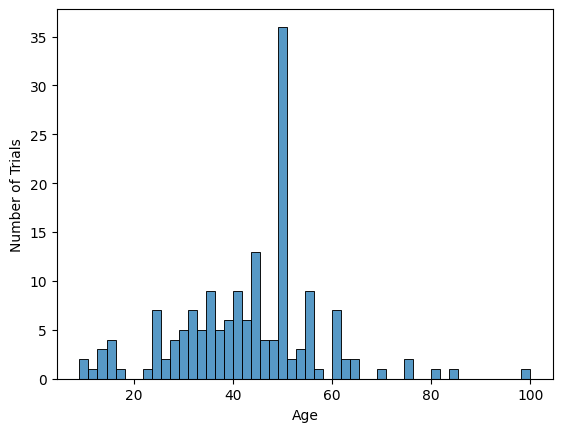

In [25]:
sns.histplot(df_encoded['Age'], bins=50)
plt.gca().set_xlabel("Age")
plt.gca().set_ylabel("Number of Trials")

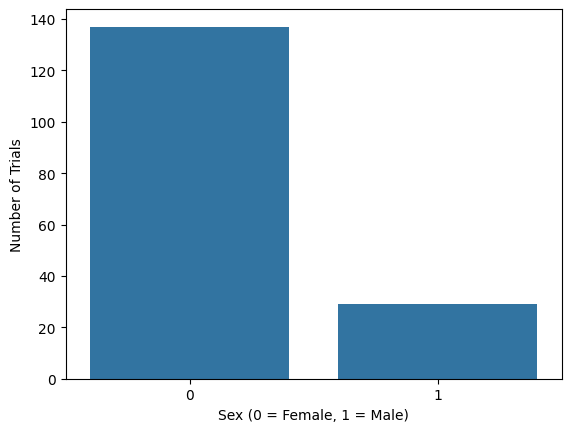

In [29]:
# Juste un count
counts = df_encoded['Sex_Male'].value_counts()
sns.barplot(x = counts.index, y = counts.values)
plt.gca().set_xlabel("Sex (0 = Female, 1 = Male)")
plt.gca().set_ylabel("Number of Trials")
plt.show()

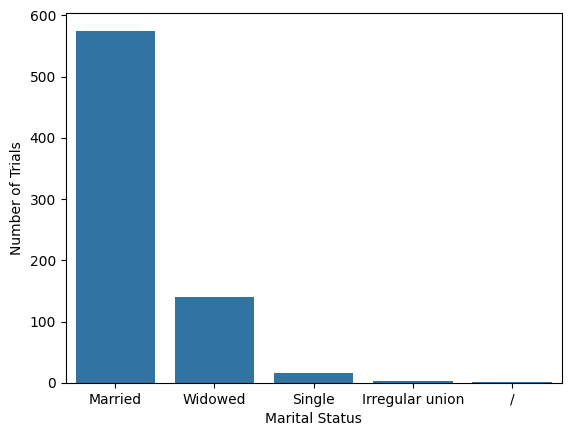

In [31]:
# Juste un count
counts = df['MaritalStatus'].value_counts()
sns.barplot(x = counts.index, y = counts.values)
plt.gca().set_xlabel("Marital Status")
plt.gca().set_ylabel("Number of Trials")
plt.show()

## 5. Linear model

In [ ]:
# Data standardization
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
def model(X, y=None):
    n_features = X.shape[1]
    
    beta = numpyro.sample("beta", dist.Normal(0, 1).expand([n_features]))
    intercept = numpyro.sample("intercept", dist.Normal(0, 1))
    
    logits = intercept + jnp.dot(X, beta)
    
    numpyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=200, num_samples=200)

mcmc.run(jax.random.PRNGKey(0), X=jnp.array(X), y=jnp.array(y))

sample: 100%|██████████| 400/400 [00:01<00:00, 285.99it/s, 7 steps of size 4.93e-01. acc. prob=0.93] 


array([[<Axes: title={'center': 'beta\nAge'}>,
        <Axes: title={'center': 'beta\nSex_Male'}>,
        <Axes: title={'center': 'beta\nMaritalStatus_Irregular union'}>],
       [<Axes: title={'center': 'beta\nMaritalStatus_Married'}>,
        <Axes: title={'center': 'beta\nMaritalStatus_Single'}>,
        <Axes: title={'center': 'beta\nMaritalStatus_Widowed'}>],
       [<Axes: title={'center': 'intercept'}>, <Axes: >, <Axes: >]],
      dtype=object)

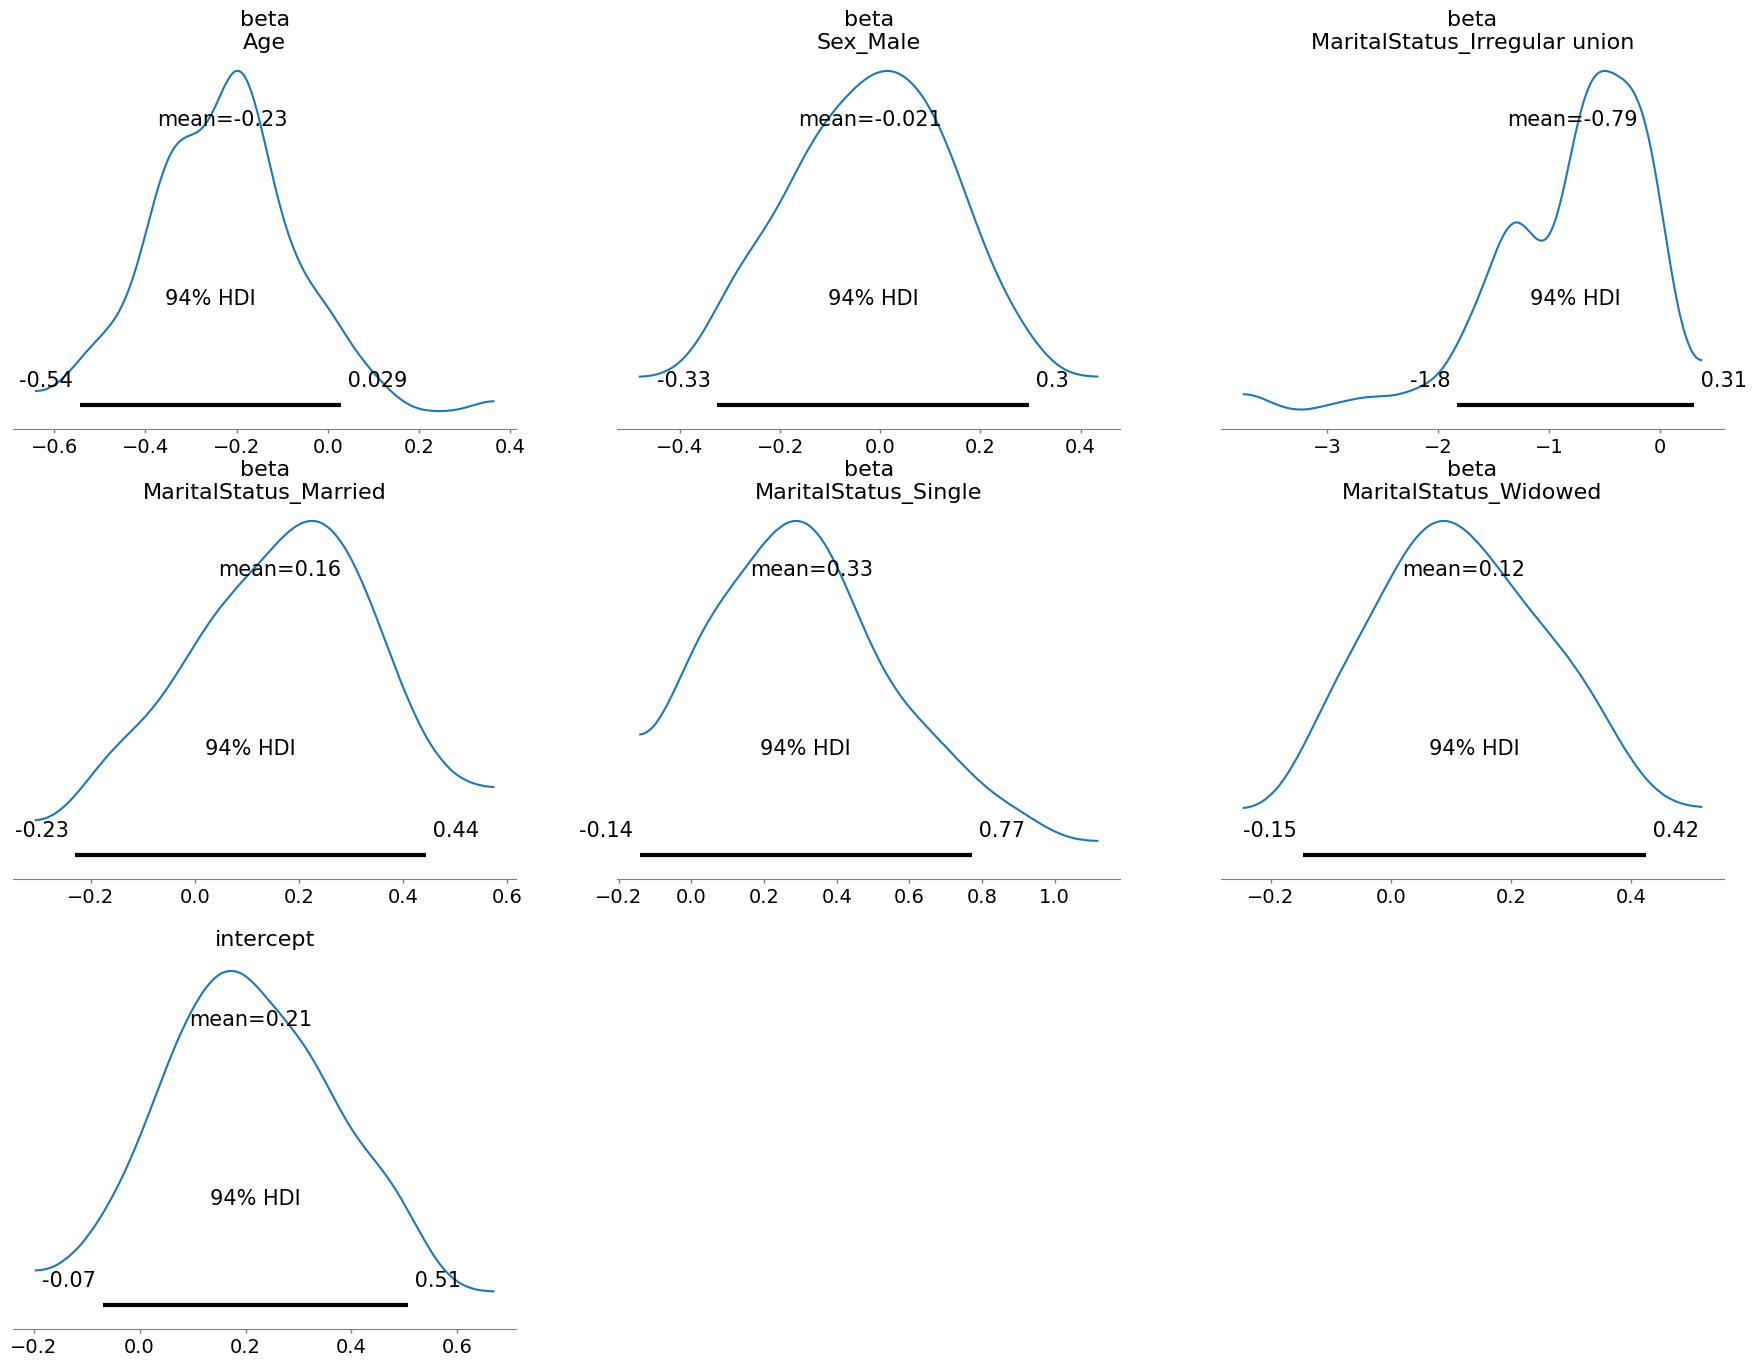

In [20]:
samples = mcmc.get_samples()

feature_names = df_encoded[variables].columns.tolist()
idata = az.from_numpyro(
    mcmc,
    coords={"features": feature_names},
    dims={"beta": ["features"]}
)
az.plot_posterior(idata, var_names=["beta", "intercept"])

In [18]:
az.summary(idata)

arviz - WARNING - Shape validation failed: input_shape: (1, 200), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[Age],-0.232,0.154,-0.545,0.029,0.013,0.010,140.0,131.0,NaN
beta[Sex_Male],-0.021,0.175,-0.326,0.297,0.011,0.012,243.0,153.0,NaN
beta[MaritalStatus_Irregular union],-0.786,0.675,-1.832,0.312,0.072,0.074,112.0,78.0,NaN
beta[MaritalStatus_Married],0.163,0.185,-0.230,0.444,0.010,0.013,320.0,182.0,NaN
beta[MaritalStatus_Single],0.330,0.257,-0.142,0.771,0.019,0.018,207.0,113.0,NaN
beta[MaritalStatus_Widowed],0.121,0.159,-0.146,0.425,0.010,0.009,236.0,178.0,NaN
intercept,0.210,0.165,-0.070,0.507,0.012,0.008,180.0,149.0,NaN
